# Taller de Deep Learning - Tarea 2

## Clasificación de Ritmos Cardíacos con LSTM

Estudiante: Enrique Oliva (214205)  
Fecha: 16/Nov/2025

Este notebook implementa un clasificador de ritmos cardíacos utilizando redes LSTM. El objetivo es clasificar señales de electrocardiograma (ECG) en 5 categorías: Normal (N), Supraventricular (S), Ventricular (V), Fusión (F) y Desconocido (Q). Se realiza un análisis exploratorio de los datos, se entrena el modelo con diferentes configuraciones de hiperparámetros, y se documentan los experimentos en Weights & Biases.

---

Importamos las librerías necesarias para el proyecto.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from torchinfo import summary
import wandb
import kagglehub
import os

c:\Users\Enrique\anaconda3\envs\tarea2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuramos el dispositivo (GPU si está disponible, sino CPU).

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 1. Descarga del Dataset

Descargamos el dataset de Heartbeat desde Kaggle.

In [3]:
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print(f"Ruta del dataset: {path}")

Ruta del dataset: C:\Users\Enrique\.cache\kagglehub\datasets\shayanfazeli\heartbeat\versions\1


Cargamos los archivos CSV de entrenamiento y test.

In [4]:
train_df = pd.read_csv(os.path.join(path, 'mitbih_train.csv'), header=None)
test_df = pd.read_csv(os.path.join(path, 'mitbih_test.csv'), header=None)

print(f'Train: {train_df.shape}')
print(f'Test: {test_df.shape}')

Train: (87554, 188)
Test: (21892, 188)


## 2. Análisis Exploratorio de Datos (EDA)

Separamos las características (X) de las etiquetas (y).

In [5]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (87554, 187), y_train: (87554,)
X_test: (21892, 187), y_test: (21892,)


Visualizamos la distribución de clases en el conjunto de entrenamiento.

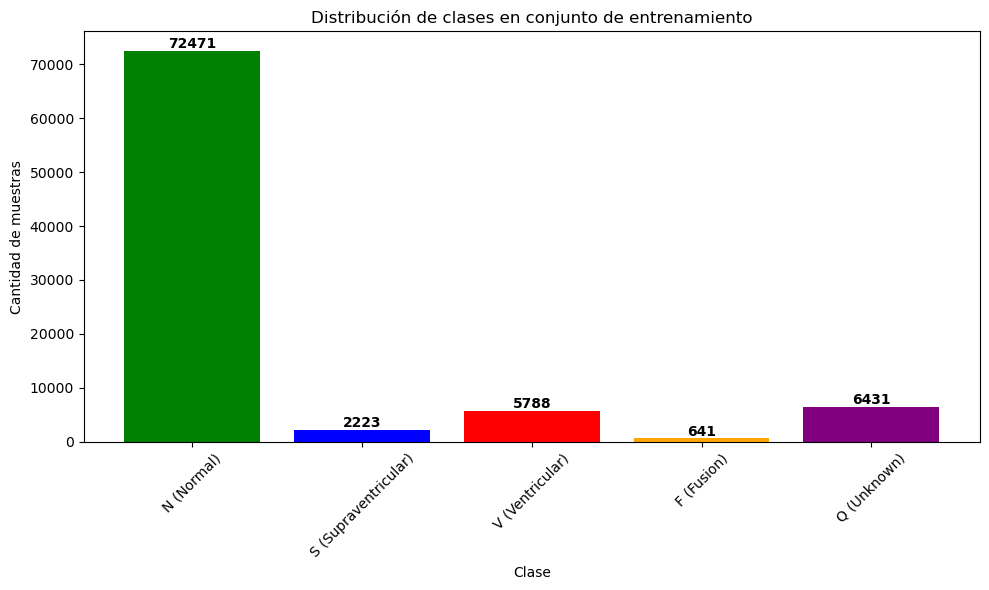

N (Normal): 82.77%
S (Supraventricular): 2.54%
V (Ventricular): 6.61%
F (Fusion): 0.73%
Q (Unknown): 7.35%


In [6]:
class_names = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(class_names, counts, color=['green', 'blue', 'red', 'orange', 'purple'])
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.title('Distribución de clases en conjunto de entrenamiento')
plt.xticks(rotation=45)
for i, v in enumerate(counts):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

for i, name in enumerate(class_names):
    print(f'{name}: {counts[i]/len(y_train)*100:.2f}%')

Visualizamos un ejemplo de señal ECG por cada clase.

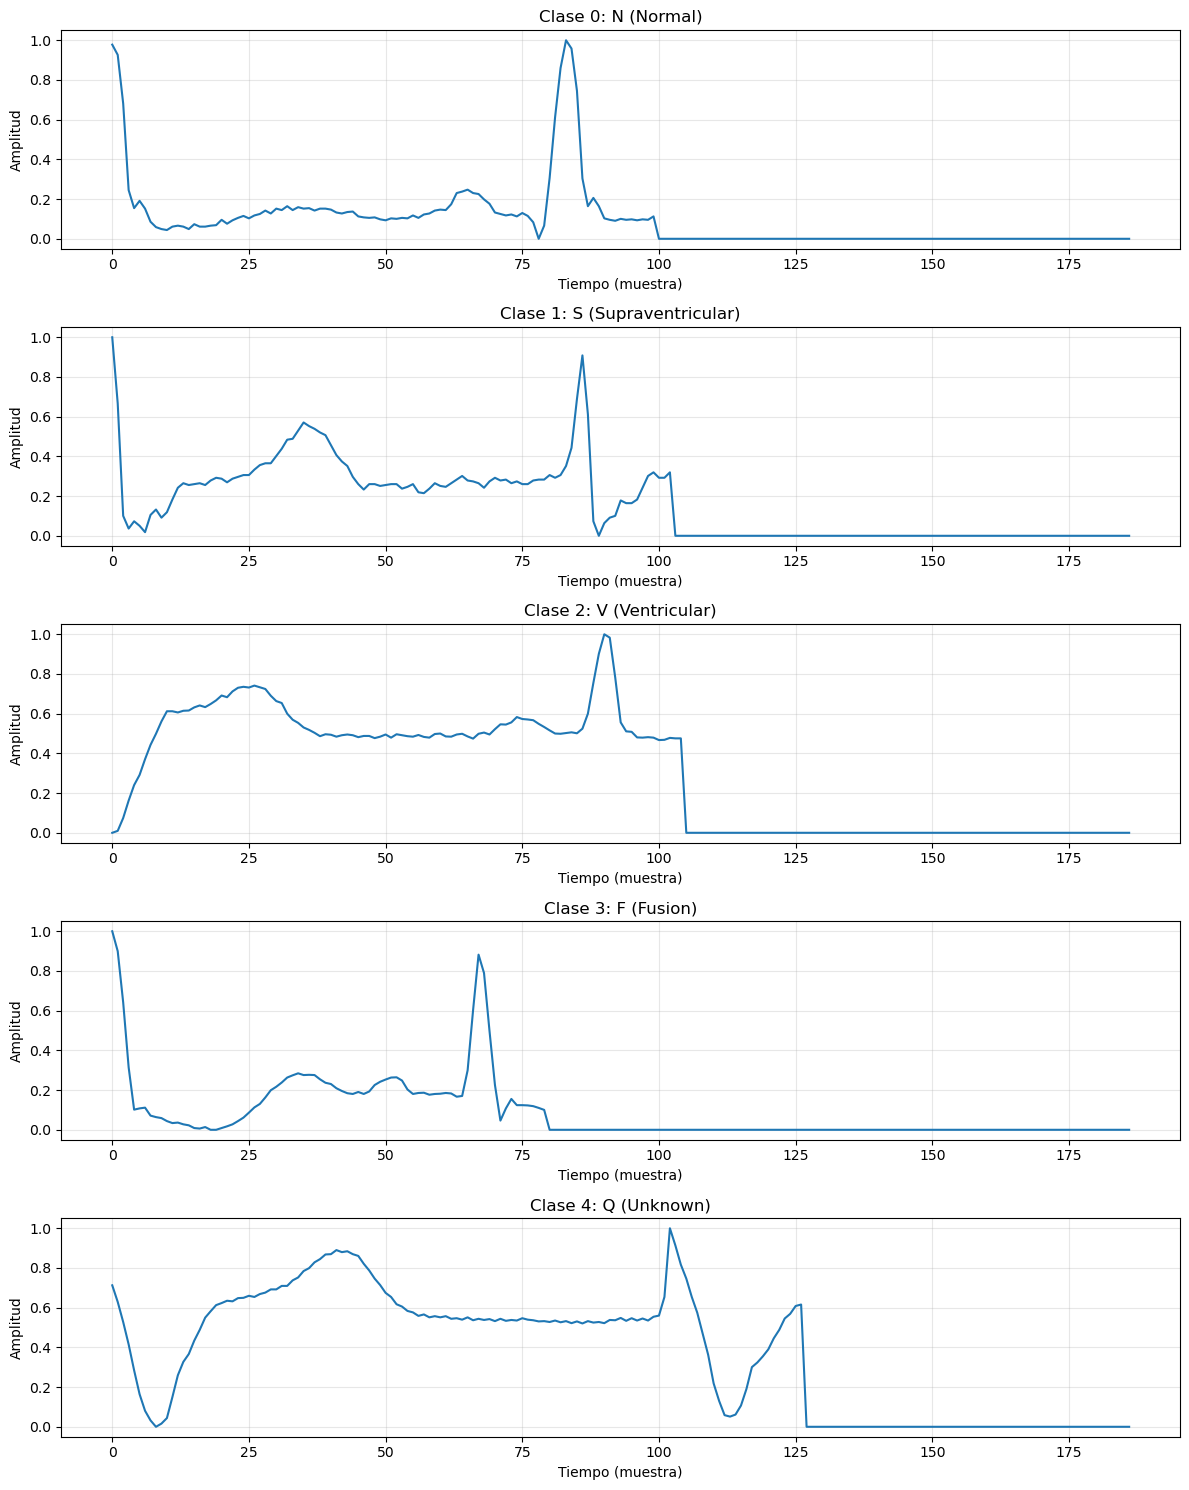

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for i in range(5):
    idx = np.where(y_train == i)[0][0]
    axes[i].plot(X_train[idx], linewidth=1.5)
    axes[i].set_title(f'Clase {i}: {class_names[i]}')
    axes[i].set_xlabel('Tiempo (muestra)')
    axes[i].set_ylabel('Amplitud')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analizamos el rango de valores de los datos.

In [8]:
print(f'Min: {X_train.min():.4f}, Max: {X_train.max():.4f}')
print(f'Media: {X_train.mean():.4f}, Std: {X_train.std():.4f}')

Min: 0.0000, Max: 1.0000
Media: 0.1743, Std: 0.2263


## 3. Preprocesamiento de Datos

**Decisiones de preprocesamiento:**
- Los datos ya están normalizados en el rango [0, 1] aproximadamente
- Las clases están desbalanceadas (clase 0 domina con 83% aprox)
- Cada latido tiene 187 valores temporales que vamos a tratar como secuencia
- Vamos a dividir el conjunto de entrenamiento en train/validation (80/20)

**Justificación:**

1. Tratamos los datos como secuencia temporal (187 timesteps × 1 feature) en lugar de 1 timestep × 187 features porque esto permite que la LSTM aprenda patrones temporales en la señal ECG, que es su fortaleza principal.

2. División 80/20 train/validation porque es estándar y funciona bien.

3. No aplicamos oversampling ni undersampling porque preferimos entrenar más épocas y dar más capacidad al modelo para que aprenda naturalmente. También probamos class weights pero resultó contraproducente (ver experimentos).

Definimos la clase Dataset personalizada para PyTorch.

In [9]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(-1)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Creamos los datasets y dividimos en train/validation (80/20).

In [10]:
full_train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f'Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 70043, Validation: 17511, Test: 21892


Creamos los DataLoaders para cargar los datos en batches.

In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_batch, sample_labels = next(iter(train_loader))
print(f'Batch: {sample_batch.shape}, Labels: {sample_labels.shape}')

Batch: torch.Size([64, 187, 1]), Labels: torch.Size([64])


## 4. Arquitectura del Modelo LSTM

Definimos la arquitectura del clasificador LSTM.

In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

Creamos una instancia del modelo y mostramos su resumen.

In [13]:
INPUT_SIZE = 1
HIDDEN_DIM = 128
NUM_LAYERS = 2
NUM_CLASSES = 5
DROPOUT = 0.0

model = LSTMClassifier(INPUT_SIZE, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
summary(model, input_size=(BATCH_SIZE, 187, INPUT_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMClassifier                           [64, 5]                   --
├─LSTM: 1-1                              [64, 187, 128]            199,168
├─Dropout: 1-2                           [64, 128]                 --
├─Linear: 1-3                            [64, 5]                   645
Total params: 199,813
Trainable params: 199,813
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.38
Input size (MB): 0.05
Forward/backward pass size (MB): 12.26
Params size (MB): 0.80
Estimated Total Size (MB): 13.10

## 5. Funciones de Entrenamiento y Evaluación

Definimos la función para entrenar una época.

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)
    
    return total_loss / total, correct / total

Definimos la función para evaluar el modelo.

In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    
    return total_loss / total, correct / total

Definimos la función principal de entrenamiento con logging a wandb.

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, experiment_name):
    wandb.init(project='Taller de IA - Tarea 2', name=experiment_name, reinit=True)
    wandb.watch(model)
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f'Época {epoch+1}/{epochs} - Train: {train_acc:.4f}, Val: {val_acc:.4f}')
    
    wandb.finish()
    
    return train_losses, train_accs, val_losses, val_accs, best_model_state

## 6. Experimentos con Wandb

Iniciamos sesión en Weights & Biases.

In [17]:
wandb.login()

wandb: Currently logged in as: eo214205 (eo214205-ort) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Entrenamiento del Modelo

Entrenamos el modelo LSTM con la configuración inicial (sin regularización).

In [18]:
model = LSTMClassifier(input_size=1, hidden_dim=128, num_layers=2, num_classes=5, dropout=0.0).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accs, val_losses, val_accs, best_model_state = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=200, experiment_name='Corrida 5 - Revertir pesos, 200 épocas'
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Época 10/200 - Train: 0.8966, Val: 0.9134
Época 20/200 - Train: 0.9654, Val: 0.9682
Época 30/200 - Train: 0.9764, Val: 0.9775
Época 40/200 - Train: 0.9828, Val: 0.9810
Época 50/200 - Train: 0.9852, Val: 0.9829
Época 60/200 - Train: 0.9891, Val: 0.9839
Época 70/200 - Train: 0.9902, Val: 0.9856
Época 80/200 - Train: 0.9917, Val: 0.9835
Época 90/200 - Train: 0.9929, Val: 0.9857
Época 100/200 - Train: 0.9935, Val: 0.9868
Época 110/200 - Train: 0.9941, Val: 0.9857
Época 120/200 - Train: 0.9956, Val: 0.9849
Época 130/200 - Train: 0.9957, Val: 0.9852
Época 140/200 - Train: 0.9943, Val: 0.9854
Época 150/200 - Train: 0.9962, Val: 0.9858
Época 160/200 - Train: 0.9972, Val: 0.9868
Época 170/200 - Train: 0.9970, Val: 0.9870
Época 180/200 - Train: 0.9971, Val: 0.9869
Época 190/200 - Train: 0.9974, Val: 0.9866
Época 200/200 - Train: 0.9973, Val: 0.9866


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇███
train_acc,▁▁▅▆▇▇▇▇▇▇██████████████████████████████
train_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▇▇▇▇███████████████████████████████████
val_loss,██▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,200
train_acc,0.99729
train_loss,0.00768
val_acc,0.98664
val_loss,0.0666


## 7. Visualización del Entrenamiento

Graficamos las curvas de entrenamiento.

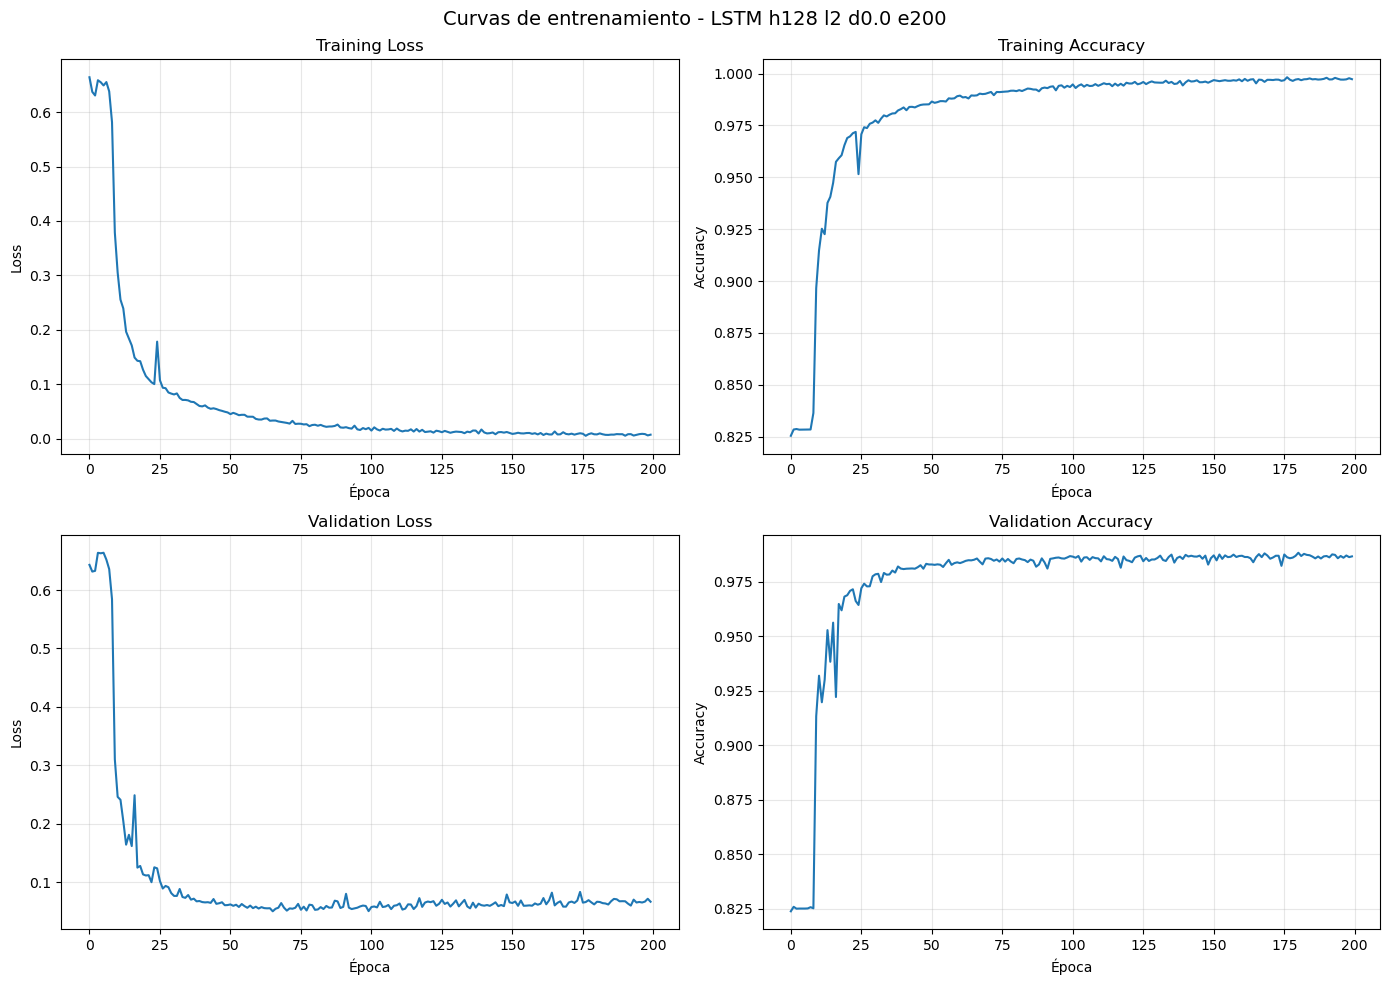

Mejor accuracy de validación: 0.9883


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_losses)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_accs)
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(val_losses)
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(val_accs)
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento - LSTM h128 l2 d0.0 e200', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Mejor accuracy de validación: {max(val_accs):.4f}')

## 8. Link a Wandb

https://wandb.ai/eo214205-ort/Taller%20de%20IA%20-%20Tarea%202

## 9. Evaluación Final en Test Set

In [20]:
model.load_state_dict(best_model_state)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

Calculamos las métricas globales requeridas.

In [21]:
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision (macro): {precision:.4f}')
print(f'Recall (macro): {recall:.4f}')
print(f'F1-Score (macro): {f1:.4f}')

Accuracy: 0.9854
Precision (macro): 0.9227
Recall (macro): 0.9136
F1-Score (macro): 0.9173


Mostramos el reporte de clasificación detallado por clase.

In [22]:
target_names = ['N (Normal)', 'S (Supra)', 'V (Ventr)', 'F (Fusion)', 'Q (Unknown)']
print(classification_report(all_labels, all_preds, target_names=target_names))

              precision    recall  f1-score   support

  N (Normal)       0.99      1.00      0.99     18118
   S (Supra)       0.89      0.80      0.84       556
   V (Ventr)       0.97      0.95      0.96      1448
  F (Fusion)       0.77      0.84      0.80       162
 Q (Unknown)       0.99      0.99      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.92      0.91      0.92     21892
weighted avg       0.99      0.99      0.99     21892



## 10. Conclusiones

Se realizaron 5 iteraciones, cada una ajustando hiperparámetros según los resultados anteriores:

| Corrida | Configuración | Val Acc | Macro F1 | Observación |
|---------|--------------|---------|----------|-------------|
| 1 | h=64, e=20 | 92.46% | 51.26% | Modelo ignora clases minoritarias (S=0%, F=0%) |
| 2 | h=64, e=50 | 98.00% | 83.91% | Más épocas ayuda. S=55%, F=75% |
| 3 | h=128, e=50 | 98.46% | 89.22% | Mayor capacidad mejora. S=69%, F=76% |
| 4 | h=128, e=50, weighted loss | 94.27% | 77.56% | Pesos por clase muy agresivos. Precision cae |
| 5 | h=128, e=200 | 98.70% | 91.73% | Revertir pesos, más épocas. S=80%, F=84% |

**Justificación de cambios:**

- **Corrida 1 → 2**: El loss seguía bajando a época 20, indicando que el modelo no había convergido.
- **Corrida 2 → 3**: Clase S con solo 55% recall sugiere que el modelo necesita más capacidad para distinguir patrones.
- **Corrida 3 → 4**: Probamos pesos por clase (técnica recomendada para datos desbalanceados) para mejorar clases minoritarias.
- **Corrida 4 → 5**: Los pesos empeoraron el F1, así que revertimos y dimos más tiempo de entrenamiento.

La corrida final corresponde a la configuración que dio mejores resultados balanceados.